In [1]:
# an example of data format this notebook will expect

# this is for a _single_ trial, we you'll need to batch for multiple trials
# to denoise any randomness in your results

import numpy as np
from typing import List, Dict, Iterable


def _generate_random_demo_data(times_to_plan: List[float],
                               performance_fields: List[float]) \
        -> Dict[str, Iterable[float]]:
    rng = np.random.default_rng()
    data_dict = {'compute time': times_to_plan}
    for _field in performance_fields:
        data_dict[_field] = rng.uniform(0.0, 1.0, size=(len(times_to_plan),))

    return data_dict

_generate_random_demo_data([0.0, 0.5, 1.0, 1.5, 2.0], ['num_steps', 'reward'])


{'compute time': [0.0, 0.5, 1.0, 1.5, 2.0],
 'num_steps': array([0.60332462, 0.59319436, 0.44142671, 0.26350113, 0.95130076]),
 'reward': array([0.31323102, 0.37616205, 0.80041878, 0.20471038, 0.07788418])}

In [2]:
# here's an example of how to some helper utilities to put together a 
# pandas dataframe easily visualizable from seaborn.

# (please don't mind that discrete quantities are randomly generated to be floats)
#... I trust you can work out the write domain for each of these fields.


planning_times = [1.0, 5.0, 10.0, 15.0]
data_fields = ['plan length', 'reward']

particle_filter_100_trials = [
    _generate_random_demo_data(planning_times, data_fields) for _ in range(5)
]

pushing_neural_process_trials = [
    _generate_random_demo_data(planning_times, data_fields) for _ in range(5)
]


In [3]:
# compile dataframes

from plotting_utils import (
    single_experiment_run_to_df,
    batch_experiment_runs_into_trials_df,
    batch_multiple_trial_dfs_into_comparison_df
)

pf100_trial_df = batch_experiment_runs_into_trials_df(list(
    map(lambda _d: single_experiment_run_to_df(_d), particle_filter_100_trials)
))

pnp_trial_df = batch_experiment_runs_into_trials_df(list(
    map(lambda _d: single_experiment_run_to_df(_d), pushing_neural_process_trials)
))

comparison_df = batch_multiple_trial_dfs_into_comparison_df(
    {
        'pf n=100': pf100_trial_df,
        'pnp': pnp_trial_df
    }
)

comparison_df

,compute time,plan length,reward,trial,method
0,1.0,0.518610,0.828119,0,pf n=100
1,5.0,0.232104,0.144784,0,pf n=100
2,10.0,0.057910,0.852359,0,pf n=100
3,15.0,0.980677,0.925948,0,pf n=100
0,1.0,0.982462,0.587755,1,pf n=100
1,5.0,0.541390,0.177308,1,pf n=100
2,10.0,0.288289,0.628246,1,pf n=100
3,15.0,0.401035,0.713190,1,pf n=100
0,1.0,0.472521,0.517519,2,pf n=100
1,5.0,0.320713,0.605840,2,pf n=100


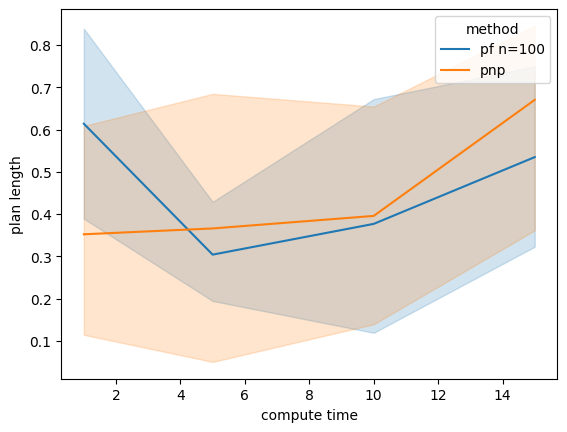

<AxesSubplot: xlabel='compute time', ylabel='reward'>

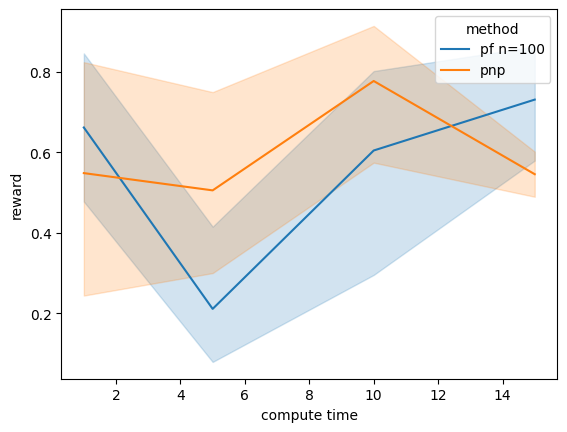

In [ ]:
# plot using seaborn
# Note... this is just a demo of how to plot.. but does not describe
# what a well-formatted plot should look like!

# In general, these plots lack: units on the axes, a good, informative title. 
# proper capitlization on the legend, axes labels, description of what
# the shaded error regions mean, etc.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.lineplot(x='compute time', y='plan length', hue='method', data=comparison_df)
plt.title('Plan Length vs. Compute Time')
plt.show()

plt.figure()
plt.title('P')
sns.lineplot(x='compute time', y='reward', hue='method', data=comparison_df)
